## **Score Matching** 🎖️

**Notebook Orquestador Local**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer 

anmedinas@gmail.com

# Ejecución local del pipeline completo

Este notebook es la versión local (sin GPU de Colab) de `orquestador_colab.ipynb`: mismas instrucciones, mismo orden, mismos scripts reales del repo (`download_data.py`, `train.py`, `train_clf.py`, `sample.py`, `evaluate.py`); nada se reimplementa acá, solo se orquesta. 

**Prerrequisito**: este notebook debe vivir dentro de la carpeta `notebooks/` de tu copia local del repo ya clonado (acá no se clona nada, a diferencia del notebook de Colab), y el kernel debe tener instaladas las dependencias de `requirements.txt` (celda "Dependencias", más abajo).

## Dispositivo

In [1]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Dispositivo detectado:", device)
if device == "cpu":
    print("Sin GPU/MPS disponible: el entrenamiento sera mas lento en CPU.")

Dispositivo detectado: mps


## Verificar directorio de trabajo

A diferencia del notebook de Colab, acá no se clona el repo: se asume que ya
estás corriendo este notebook desde dentro de tu copia local. Esta celda solo
ubica la raíz del repo (la carpeta que contiene `train.py`) y se posiciona
ahí, para que las rutas relativas (`checkpoints/`, `figures/`, etc.)
coincidan con las que usan los scripts.

In [2]:
import os
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for path in [start] + list(start.parents):
        if (path / "train.py").exists():
            return path
    raise FileNotFoundError("No se encontro train.py en ningun directorio padre de " + str(start))


repo_root = find_repo_root(Path.cwd())
os.chdir(repo_root)

print("Directorio de trabajo:", os.getcwd())
!git log --oneline -1

Directorio de trabajo: /Users/anmedinas/Personales/Programas/MDS/2026-01/MA5606-1 Tópicos Matemáticos en Aprendizaje de Máquinas, Redes Neuronales y Aprendizaje Profundo/score_matching
7715ee0 (HEAD -> main, origin/main, origin/HEAD) feat: update orquestadores + README


# Arquitectura 

La arquitectura de la solución, se encuentra reflejada en el siguiente *pipeline*:

![Pipeline](../figures/graph.png)

**Rama de difusión:**

* **Data (MNIST)** (`download_data.py`): descarga y deja disponibles las 60000/10000 imágenes de entrenamiento/test, normalizadas a `[-1,1]`.

* **UNet** (`model.py`): define la arquitectura de la red de difusión (`class Modelo`). Es solo el módulo con la arquitectura; no se ejecuta sola, la importan `train.py`, `sample.py` y `evaluate.py`.

![Arquitectura UNet](../figures/unet_sm.png)

* **Train (Cond, cfg)** (`train.py`): el mismo script, se ejecuta dos veces. Un solo flag cambia entre ambas instancias (cada instancia, guarda su propio checkpoint):

  ```python
  # red condicional pura (nunca ve el token nulo)
  python train.py --label-dropout 0.0 --out checkpoints
  #   -> checkpoints/modelo_cond.pt

  # red con classifier-free guidance (CFG)
  python train.py --label-dropout 0.1 --out checkpoints
  #   -> checkpoints/modelo_cfg.pt
  ```

  ¿Qué hace el args `--label-dropout`?. En cada paso de entrenamiento, con esa
  probabilidad la etiqueta real `y` se reemplaza por el **token nulo** $\empty$,
  de forma aleatoria e independiente por muestra. Con `label_dropout=0.0`(`modelo_cond`) esto nunca pasa: la red solo aprende a generar condicionada a una clase, y por eso siempre se muestrea con `w=1` (no tiene sentido combinarla con una versión "sin condicionar" que jamás vio). Con `label_dropout=0.1` (`modelo_cfg`) la red aprende dos tareas a la vez< condicionada y sin condicionar, lo que permite combinar ambas predicciones en el muestreo con la regla de CFG (celda "Sampling", más abajo).

* **Sampling** (`sample.py`): genera imágenes integrando la SDE reversa (Euler–Maruyama) aplicando la regla de CFG, a partir de cualquiera de los dos checkpoints entrenados.

**Rama del clasificador (abajo):**

* **CNN** (`model_clf.py`): define la arquitectura del clasificador auxiliar (`class Clasificador`). También es solo el módulo.
  
![Arquitectura CNN](../figures/cnn_sm.png)

- **Train (Classifier)** (`train_clf.py`): entrena el clasificador sobre los datos reales, de forma independiente a las redes de difusión; no necesita esperar a que `UNet`/`Train (Cond, cfg)` terminen, podría correr en paralelo.

**Convergencia:**

* **Evaluation** (`evaluate.py`): el único script que importa ambas arquitecturas a la vez (`model.py` y `model_clf.py`). Genera muestras con las redes de difusión y usa el clasificador entrenado como juez automático, midiendo fidelidad condicional y diversidad intra-clase.

## Dependencias

A diferencia de Colab, acá no hay nada preinstalado: se instala
`requirements.txt` completo, incluyendo `torch`. Si tu máquina tiene GPU
NVIDIA y quieres usar CUDA, instala primero la build de PyTorch que
corresponda a tu versión de CUDA (ver https://pytorch.org/get-started/locally/)
*antes* de correr esta celda, para no pisarla con la build CPU-only que trae
PyPI por defecto. En Apple Silicon (MPS) no hace falta nada especial: la
build estándar de PyPI ya trae soporte MPS.

In [3]:
!pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Datos

In [4]:
!python download_data.py

## Hiperparámetros (editables)

Ajusta y vuelve a correr esta celda antes de entrenar. `label_dropout_cfg`
queda en 0.1 (valor estandar en la literatura de CFG); el resto son puntos
de partida razonables, no valores finales. En CPU/MPS conviene bajar
`n_epochs_diffusion`/`n_epochs_clf` para una primera pasada rápida.

In [5]:
n_epochs_diffusion = 40
n_epochs_clf = 8
batch_size = 256
lr = 3e-4
lr_clf = 1e-3
label_dropout_cfg = 0.1
seed = 0
n_sampling_steps = 1000
w_cfg = 3.0

## Entrenamiento (red condicional pura) (`modelo_cond.pt`, `label_dropout=0.0`)

In [6]:
!python train.py \
  --epochs {n_epochs_diffusion} --batch-size {batch_size} --lr {lr} \
  --device {device} --seed {seed} --label-dropout 0.0 --out checkpoints

epoch 1/40  loss 0.1694
epoch 2/40  loss 0.0779
epoch 3/40  loss 0.0658
epoch 4/40  loss 0.0610
epoch 5/40  loss 0.0570
epoch 6/40  loss 0.0546
epoch 7/40  loss 0.0536
epoch 8/40  loss 0.0521
epoch 9/40  loss 0.0503
epoch 10/40  loss 0.0507
epoch 11/40  loss 0.0496
epoch 12/40  loss 0.0493
epoch 13/40  loss 0.0486
epoch 14/40  loss 0.0476
epoch 15/40  loss 0.0471
epoch 16/40  loss 0.0470
epoch 17/40  loss 0.0464
epoch 18/40  loss 0.0465
epoch 19/40  loss 0.0462
epoch 20/40  loss 0.0460
epoch 21/40  loss 0.0457
epoch 22/40  loss 0.0451
epoch 23/40  loss 0.0452
epoch 24/40  loss 0.0447
epoch 25/40  loss 0.0448
epoch 26/40  loss 0.0451
epoch 27/40  loss 0.0445
epoch 28/40  loss 0.0446
epoch 29/40  loss 0.0442
epoch 30/40  loss 0.0439
epoch 31/40  loss 0.0442
epoch 32/40  loss 0.0439
epoch 33/40  loss 0.0438
epoch 34/40  loss 0.0437
epoch 35/40  loss 0.0435
epoch 36/40  loss 0.0435
epoch 37/40  loss 0.0431
epoch 38/40  loss 0.0433
epoch 39/40  loss 0.0435
epoch 40/40  loss 0.0432
checkpoin

## Entrenamiento (red con CFG) (`modelo_cfg.pt`, `label_dropout={label_dropout_cfg}`)

In [7]:
!python train.py \
  --epochs {n_epochs_diffusion} --batch-size {batch_size} --lr {lr} \
  --device {device} --seed {seed} --label-dropout {label_dropout_cfg} --out checkpoints

epoch 1/40  loss 0.1653
epoch 2/40  loss 0.0772
epoch 3/40  loss 0.0657
epoch 4/40  loss 0.0605
epoch 5/40  loss 0.0575
epoch 6/40  loss 0.0541
epoch 7/40  loss 0.0533
epoch 8/40  loss 0.0521
epoch 9/40  loss 0.0507
epoch 10/40  loss 0.0501
epoch 11/40  loss 0.0494
epoch 12/40  loss 0.0490
epoch 13/40  loss 0.0487
epoch 14/40  loss 0.0480
epoch 15/40  loss 0.0476
epoch 16/40  loss 0.0472
epoch 17/40  loss 0.0470
epoch 18/40  loss 0.0464
epoch 19/40  loss 0.0461
epoch 20/40  loss 0.0461
epoch 21/40  loss 0.0460
epoch 22/40  loss 0.0455
epoch 23/40  loss 0.0457
epoch 24/40  loss 0.0451
epoch 25/40  loss 0.0449
epoch 26/40  loss 0.0450
epoch 27/40  loss 0.0449
epoch 28/40  loss 0.0446
epoch 29/40  loss 0.0445
epoch 30/40  loss 0.0445
epoch 31/40  loss 0.0448
epoch 32/40  loss 0.0445
epoch 33/40  loss 0.0443
epoch 34/40  loss 0.0443
epoch 35/40  loss 0.0435
epoch 36/40  loss 0.0437
epoch 37/40  loss 0.0437
epoch 38/40  loss 0.0434
epoch 39/40  loss 0.0437
epoch 40/40  loss 0.0438
checkpoin

## Entrenamiento (clasificador auxiliar) (`clasificador.pt`)

In [8]:
!python train_clf.py \
  --epochs {n_epochs_clf} --batch-size {batch_size} --lr {lr_clf} \
  --device {device} --seed {seed} --out checkpoints

epoch 1/8  loss 0.2654
epoch 2/8  loss 0.0628
epoch 3/8  loss 0.0458
epoch 4/8  loss 0.0349
epoch 5/8  loss 0.0291
epoch 6/8  loss 0.0237
epoch 7/8  loss 0.0202
epoch 8/8  loss 0.0175
checkpoint guardado en checkpoints/clasificador.pt
curva de perdida guardada en figures/loss/clasificador_loss.png


## Curvas de pérdida (generadas por los scripts, solo se muestran aqui)

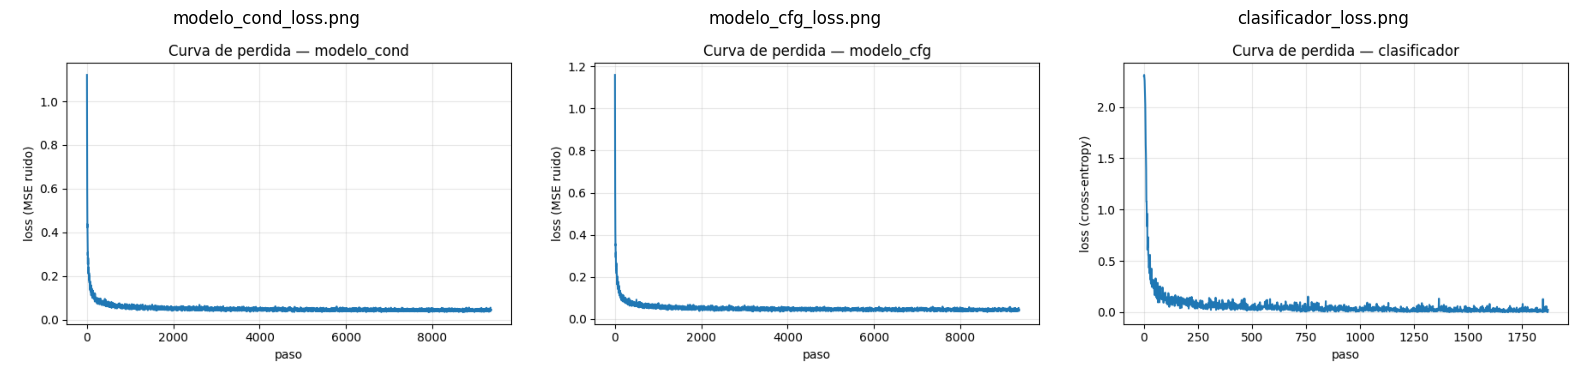

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

loss_files = ["modelo_cond_loss.png", "modelo_cfg_loss.png", "clasificador_loss.png"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, loss_files):
    ax.imshow(Image.open(f"figures/loss/{name}"))
    ax.axis("off")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Muestreo (opcional)

Con los tres checkpoints ya entrenados, esta celda genera imágenes nuevas
integrando la SDE reversa (Euler–Maruyama, ver `sample.py`) y las muestra
lado a lado para comparar visualmente el efecto de CFG:

- **`modelo_cond`, `w=1`**: red condicional pura, sin guía adicional.
- **`modelo_cfg`, `w=1`**: misma red entrenada con CFG, pero sin aplicar guía (equivale al caso puramente condicional).
- **`modelo_cfg`, `w={w_cfg}`**: la misma red con guía CFG activa (`w>1`), que empuja las muestras hacia dígitos más "prototípicos" de su clase, a costa de menor diversidad dentro de cada clase.

Es opcional porque no hace falta para entrenar; sirve para inspeccionar
cualitativamente los resultados antes de la evaluación cuantitativa de la
celda siguiente.

muestras guardadas en figures/samples/modelo_cond_w1.png
muestras guardadas en figures/samples/modelo_cfg_w1.png
muestras guardadas en figures/samples/modelo_cfg_w3.png


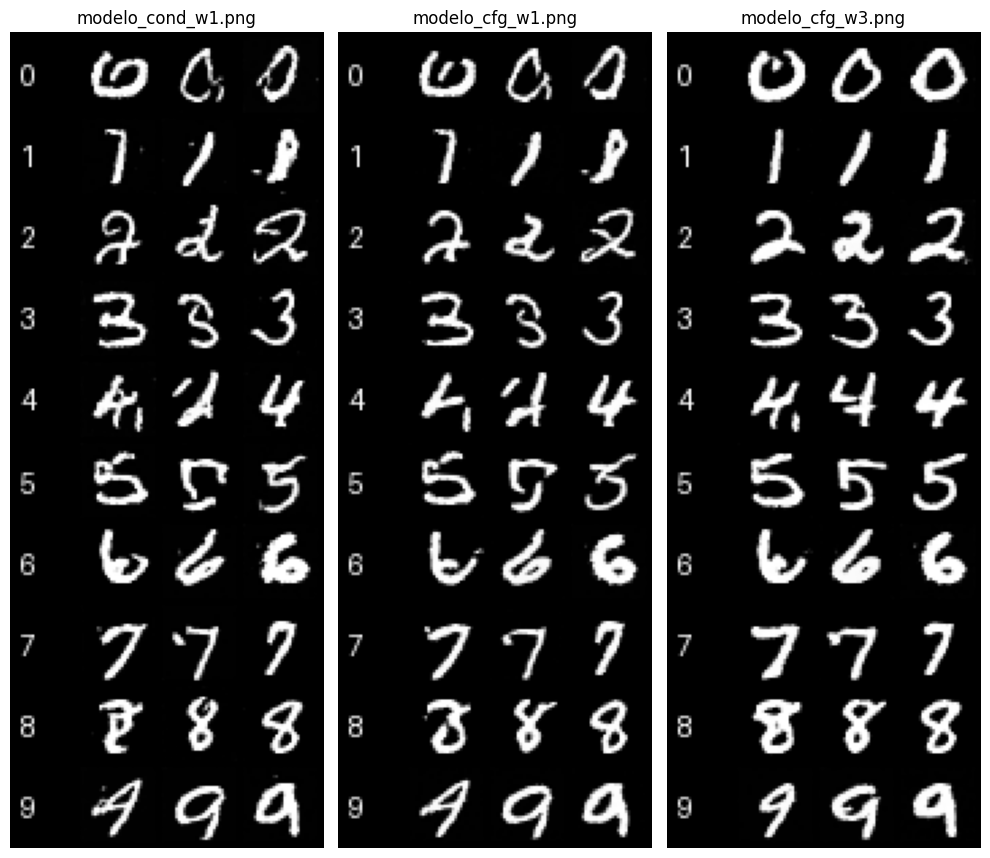

In [10]:
!python sample.py --checkpoint checkpoints/modelo_cond.pt \
  --n-steps {n_sampling_steps} --w 1.0 --n-samples 30 --device {device} \
  --seed {seed} --out figures/samples
!python sample.py --checkpoint checkpoints/modelo_cfg.pt \
  --n-steps {n_sampling_steps} --w 1.0 --n-samples 30 --device {device} \
  --seed {seed} --out figures/samples
!python sample.py --checkpoint checkpoints/modelo_cfg.pt \
  --n-steps {n_sampling_steps} --w {w_cfg} --n-samples 30 --device {device} \
  --seed {seed} --out figures/samples

import matplotlib.pyplot as plt
from PIL import Image

sample_files = ["modelo_cond_w1.png", "modelo_cfg_w1.png", f"modelo_cfg_w{w_cfg:g}.png"]
fig, axes = plt.subplots(1, 3, figsize=(10, 14))
for ax, name in zip(axes, sample_files):
    ax.imshow(Image.open(f"figures/samples/{name}"))
    ax.axis("off")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Evaluación (`evaluate.py`)

Esta es la comparación cuantitativa (no solo visual) entre el modelo sin
guía y el modelo con guía: genera muestras nuevas con `modelo_cond` (`w=1`)
y con `modelo_cfg` (`w={w_cfg}`), y usa `clasificador.pt` como "juez"
automático para medir, por clase y en promedio:

- **Fidelidad condicional**: de las imágenes generadas pidiendo la clase `y`, ¿qué fracción reconoce el clasificador como `y`? Mide si el modelo genera lo que se le pidió.
- **Diversidad intra-clase**: distancia L2 promedio entre pares de imágenes generadas para una misma clase. Mide si el modelo no colapsa a un único dígito "prototípico" por clase.

El resultado esperado (y el que se obtuvo en las corridas de referencia) es
que CFG (`w>1`) sube la fidelidad a costa de algo de diversidad: el
guiado empuja las muestras hacia el "centro" de la clase.

tabla guardada en figures/evaluate/fidelidad_diversidad.csv
grafico guardado en figures/evaluate/fidelidad_por_clase.png
grafico guardado en figures/evaluate/diversidad_por_clase.png
modelo_cond (w=1): fidelidad promedio=0.904  diversidad promedio=19.464
modelo_cfg (w=3): fidelidad promedio=1.000  diversidad promedio=16.903


,red,w,clase,fidelidad,diversidad
0,modelo_cond (w=1),1.0,0,0.950,20.924170
1,modelo_cond (w=1),1.0,1,0.830,15.411528
2,modelo_cond (w=1),1.0,2,0.910,21.325659
3,modelo_cond (w=1),1.0,3,0.880,19.963984
4,modelo_cond (w=1),1.0,4,0.870,19.595959
5,modelo_cond (w=1),1.0,5,0.930,20.590714
6,modelo_cond (w=1),1.0,6,0.950,19.513655
7,modelo_cond (w=1),1.0,7,0.910,18.945711
8,modelo_cond (w=1),1.0,8,0.890,20.090849
9,modelo_cond (w=1),1.0,9,0.920,18.274815


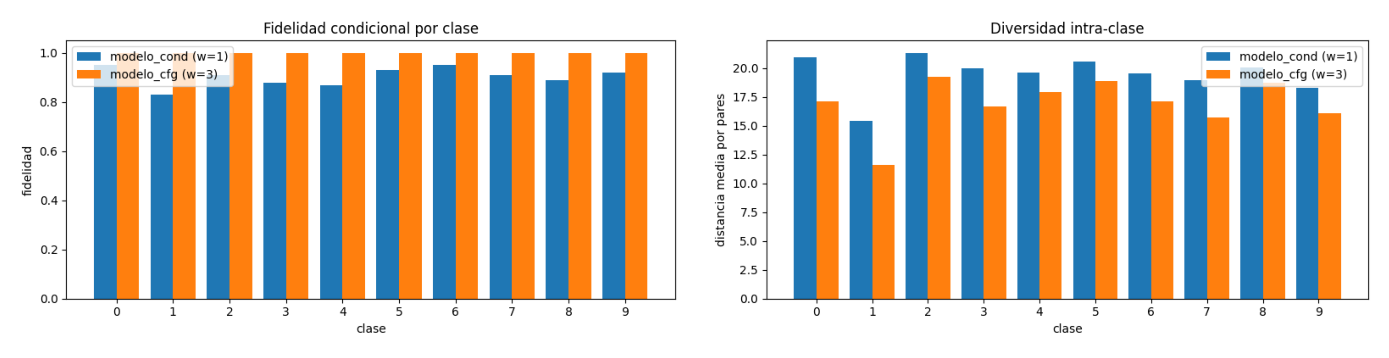

In [11]:
!python evaluate.py --w {w_cfg} --n-samples 1000 --n-steps {n_sampling_steps} \
  --device {device} --seed {seed} --out figures/evaluate

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

tabla = pd.read_csv("figures/evaluate/fidelidad_diversidad.csv")
display(tabla)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(Image.open("figures/evaluate/fidelidad_por_clase.png"))
axes[1].imshow(Image.open("figures/evaluate/diversidad_por_clase.png"))
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Resultados

A diferencia de Colab, acá no hace falta descargar nada: los checkpoints y
las figuras quedaron guardados directamente en tu copia local del repo
(`checkpoints/`, `figures/`). Esta celda solo lista lo que se generó.

In [12]:
from pathlib import Path

for carpeta in ["checkpoints", "figures"]:
    print(f"\n{carpeta}/")
    for p in sorted(Path(carpeta).rglob("*")):
        if p.is_file():
            print(" ", p.relative_to("."))


checkpoints/
  checkpoints/.DS_Store
  checkpoints/.gitkeep
  checkpoints/clasificador.pt
  checkpoints/modelo_cfg.pt
  checkpoints/modelo_cond.pt

figures/
  figures/cnn_sm.png
  figures/evaluate/.gitkeep
  figures/evaluate/diversidad_por_clase.png
  figures/evaluate/fidelidad_diversidad.csv
  figures/evaluate/fidelidad_por_clase.png
  figures/graph.png
  figures/logo.png
  figures/loss/.DS_Store
  figures/loss/.gitkeep
  figures/loss/clasificador_loss.png
  figures/loss/modelo_cfg_loss.png
  figures/loss/modelo_cond_loss.png
  figures/pipeline.png
  figures/samples/.DS_Store
  figures/samples/.gitkeep
  figures/samples/comparacion_w.png
  figures/samples/modelo_cfg_w1.png
  figures/samples/modelo_cfg_w3.png
  figures/samples/modelo_cond_w1.png
  figures/unet_sm.png


## Informe

El desarrollo teórico completo (derivación de la pérdida DSM, la relación
entre $s_\theta$, $\epsilon_\theta$ y $u_\theta$, la regla de CFG, y el análisis de los resultados de fidelidad/diversidad) está en `informe/informe.pdf` del repositorio. Este notebook, más que nada, muestra el *cómo se reprodujo*, mientras que el informe es el *por qué* de cada decisión de diseño.